# Imputing Missing values 

---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)

### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)
---

1. `Simple Imputation Techniques` 
  * Mean/Median Imputation : Replacing value with mean of median in numerical data 
  * Mode : Replacing with mode in categorical data
2. `KNN Imputation` 
3. `Regression Imputation` 
4. `Decision Tree and Random Forests`
5. `Advanced Techniques` : 
   - **Multiple Imputation by Chained Equations (MICE):** This is a more sophisticated technique that models each variable with missing values as a function of other variables in a round-robin fashion.
   - **Deep Learning Methods:** Neural networks, especially autoencoders, can be effective in imputing missing values in complex datasets.
6. `  Time Series Specific Methods ` : Forward fill and backward fill.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 



# 1. Simple Imputation Techinques 
## 1.1 Mean Imputation 

### 1.1.1 Example 1 

In [2]:
data = sns.load_dataset("titanic")
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
data.isnull().sum().sort_values(ascending=False) 

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [4]:
# We can see that there are some missing values in the dataset. We can impute these missing values using different techniques.
# The function data.drop() have parameters 
# 1. axis: 0 for rows and 1 for columns
# 2. inplace: True for making changes in the original dataset and False for creating a new dataset with the changes. By default it is False.
data.drop("deck", axis=1, inplace=True) 
data.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [5]:
data["age"] = data["age"].fillna(data["age"].mean())


In [6]:
data.isnull().sum().sort_values(ascending=False)

embark_town    2
embarked       2
sex            0
age            0
survived       0
pclass         0
parch          0
sibsp          0
class          0
fare           0
who            0
adult_male     0
alive          0
alone          0
dtype: int64

### 1.1.2 example 2


In [7]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit([[1, 2], [np.nan, 3], [7, 6]])
SimpleImputer()
X = [[np.nan, 2], [6, np.nan], [7, 6]]
print(imp.transform(X))

[[4.         2.        ]
 [6.         3.66666667]
 [7.         6.        ]]


## 1.2 Mode Imputation 

### 1.2.1 Example 1 

In [8]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [9]:
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])
data["embark_town"]=data["embark_town"].fillna(data["embark_town"].mode()[0])

# mode[0] means we are replacing with first mode 

data.isnull().sum().sort_values(ascending=False)    



survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### 1.2.2 Example 2 


In [10]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imp.fit([[1, 2], [np.nan, 3], [7, 6]])
SimpleImputer()
X = [[np.nan, 2], [6, np.nan], [7, 6]]
print(imp.transform(X))

[[1. 2.]
 [6. 2.]
 [7. 6.]]


# 2. K-Nearest Neighbors (KNN)
>  Uses Euclidean distance to find similar rows.
> 
> Uses k nearest neighbors.
> 
> Missing values are filled using average of neighbors.
> 
> Different features in the same row may use different neighbors.
> 
> If no neighbors are available → dataset mean is used.
> 
> If a feature is missing in all rows, it is removed. 

### 2.1 Simple example 

In [11]:
from sklearn.impute import KNNImputer
X = [[1, 2 , np.nan], [np.nan, 3 , 8], [7, np.nan , 6]] 
imputer = KNNImputer(n_neighbors = 2 , weights ="uniform")
imputer.fit_transform(X)
# imputer.fit(X).transform(X)
# fit_transform is the combination of both fit and transform , you can write in this way , imputer.fit(X).transform(X)

array([[1. , 2. , 7. ],
       [4. , 3. , 8. ],
       [7. , 2.5, 6. ]])

### 2.2 With titanic dataset 

In [12]:
df = sns.load_dataset("titanic") 
df.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [13]:
imputerTitanic = KNNImputer(n_neighbors = 4 )
df["age"] = imputerTitanic.fit_transform(df[["age"]])
df.isnull().sum().sort_values(ascending=False) 

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

# 3. Regression imputation 

In [14]:
df = sns.load_dataset('titanic')

# check the number of missing values in each column
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [15]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer 
# max_iter means the maximum number of times the imputer will repeat the process of predicting and updating missing values.
imputer = IterativeImputer(max_iter=10) 
df['age'] = imputer.fit_transform(df[['age']])
df.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

# 4. Imputing Using Random Forests

Random Forest is a machine learning algorithm that uses many decision trees together to make predictions.

>Instead of relying on one tree, it builds many trees on different random samples of the data and then combines their predictions

`**Steps for random forest prediction**`
- **Step 1** Separate rows with known values and missing values.
- **Step 2** Train Random Forest model.
- **Step 3** Predict the value .

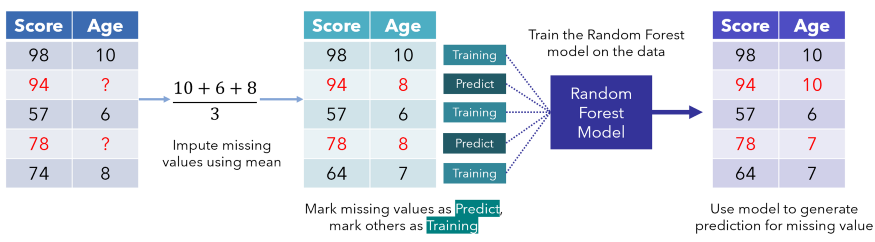

## 4.1 Example 1 

In [17]:
from sklearn.ensemble import RandomForestRegressor

data = {
    "Age":[25,30,35,40],
    "Experience":[2,5,7,10],
    "Salary":[50000,None,70000,90000]
}

df = pd.DataFrame(data)
df.head()

,Age,Experience,Salary
0,25,2,50000.0
1,30,5,NaN
2,35,7,70000.0
3,40,10,90000.0


In [18]:
# separating train and test data
train = df[df["Salary"].notnull()]
test = df[df["Salary"].isnull()]

In [19]:
# defining features and target variable 
X_train = train[["Age","Experience"]]
y_train = train["Salary"]
X_test = test[["Age","Experience"]]
model = RandomForestRegressor()

model.fit(X_train, y_train)

predicted_salary = model.predict(X_test)

df.loc[df["Salary"].isnull(),"Salary"] = predicted_salary
print(df)

   Age  Experience   Salary
0   25           2  50000.0
1   30           5  62800.0
2   35           7  70000.0
3   40          10  90000.0


## 4.2 Example 2

Raw Dataset

     │
     ▼
1️⃣ Data Cleaning

     │
     ▼
2️⃣ Handle Missing Values

     │
     ▼
3️⃣ Encode Categorical Variables

     │
     ▼
4️⃣ Split Data (Train / Test)

     │
     ▼
5️⃣ Train Machine Learning Model

     │
     ▼
6️⃣ Evaluate Model Performance

     │
     ▼
7️⃣ Predict Missing Values

     │
     ▼
8️⃣ Fill Missing Values in Dataset

     │
     ▼
9️⃣   Decode Labels

     │
     ▼
Final Clean Dataset

10    

     │
     ▼

     Save the data in csv file 

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
df = sns.load_dataset("titanic")
df.isnull().sum().sort_values(ascending = False)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [21]:
df.drop("deck", axis=1, inplace=True)
df.isnull().sum().sort_values(ascending = False)

age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
parch            0
sibsp            0
class            0
fare             0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

In [22]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


 > Encoding the data 

 * Remember to take only those variables that can affect the age , We are taking more just for example . 

In [23]:
from sklearn.preprocessing import LabelEncoder

columns_to_encode = {"sex" , "embarked"  , "who" , "class", "embark_town", "alive"}
# create a dictionary to store the label encoders for each column
label_encoders = {}

#  loop to apply label encoder to every column 
for col in columns_to_encode: 
#    create a label encoder object for each column  
    le = LabelEncoder() 
    # df[col]   will update the column in the dataset with the encoded values after fitting and
    #  transforming the column using label encoder
    df[col] = le.fit_transform(df[col])
    # Store the encoder in the dictionary , because later on we might need to convert the encoded values back to original values
    label_encoders[col] = le 
    # now dictionnary is looking like this 
    # label_encoders = {
    #     "sex": LabelEncoder(),
    #     "embarked": LabelEncoder(),................. and so on for other columns 
# }
    # Check the data is encoded or not
df.head()
     

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


#### Imputing missing values of age first 

* first we need to split the dataset 

In [24]:
# splitting the data into 2 sets , missing values and non missing values
missing_values = df[df["age"].isnull()]
non_missing_values = df[df["age"].notnull()] 

* Before going further , let us have a look on dataset whether it is splitted or not 
  

In [25]:
print("The original dataset have shape" , df.shape)
print("The dataset with missing values have shape" , missing_values.shape)
print("The dataset with non missing values have shape" , non_missing_values.shape)

The original dataset have shape (891, 14)
The dataset with missing values have shape (177, 14)
The dataset with non missing values have shape (714, 14)


> Age were having 177 missing , this means that we have splitted the dataset correctly 

In [26]:
missing_values.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
5,0,3,1,NaN,0,0,8.4583,1,2,1,True,1,0,True
17,1,2,1,NaN,0,0,13.0000,2,1,1,True,2,1,True
19,1,3,0,NaN,0,0,7.2250,0,2,2,False,0,1,True
26,0,3,1,NaN,0,0,7.2250,0,2,1,True,0,0,True
28,1,3,0,NaN,0,0,7.8792,1,2,2,False,1,1,True


In [27]:
non_missing_values.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [28]:
#  We have to drop the variable "age" from X , because now it is target variable 
# and we have to predict it using other variables in the dataset. So we will drop it from X and keep it in y.
X = non_missing_values.drop("age", axis=1)
y = non_missing_values["age"] 

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# creating and fitting the model  , 
# n_estimators is the number of trees in the random forest and random_state is used for reproducibility of results.
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train) 

# predicting the missing values in the test set
y_pred = model.predict(X_test) 

# evaluating the model
print("RMSE for Random Forest Imputation: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score for Random Forest Imputation: ", r2_score(y_test, y_pred))
print("MAE for Random Forest Imputation: ", mean_absolute_error(y_test, y_pred))
print("MAPE for Random Forest Imputation: ", mean_absolute_percentage_error(y_test, y_pred))


RMSE for Random Forest Imputation:  11.377441661310241
R2 Score for Random Forest Imputation:  0.30181636515412325
MAE for Random Forest Imputation:  8.74831615430923
MAPE for Random Forest Imputation:  0.410074907133913


In [29]:
missing_values.isnull().sum().sort_values(ascending=False)

age            177
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
embark_town      0
alive            0
alone            0
dtype: int64

In [30]:
y_pred = model.predict(missing_values.drop("age", axis=1))
y_pred

array([31.03      , 35.94166667, 17.8       , 37.33666667, 19.7       ,
       27.09227041, 39.8       , 17.6       , 20.8       , 34.15      ,
       30.46022353, 35.45      , 17.6       , 22.4       , 30.9       ,
       39.35      , 23.1       , 27.09227041, 30.46022353, 18.5       ,
       30.46022353, 30.46022353, 27.09227041, 27.78253968, 28.8       ,
       30.46022353, 53.05472222, 29.25      , 33.35714286, 31.41916667,
       33.38333333, 21.625     , 29.3       , 61.1       , 24.19      ,
       22.625     , 28.4       , 49.9       , 29.        , 53.05472222,
       17.6       , 21.625     , 29.25555556, 27.09227041, 26.8       ,
       35.7       , 25.        , 29.        , 31.41916667, 26.6       ,
       53.05472222, 27.94166667, 55.        , 17.6       , 33.96055556,
       61.1       , 39.35      , 38.3       , 17.6       , 23.        ,
       33.45      , 30.46022353, 30.72      , 21.625     , 25.5       ,
       38.1       , 27.09227041, 24.9       , 60.8       , 37.33

In [31]:
missing_values["age"] = y_pred
missing_values.isnull().sum().sort_values(ascending=False)

C:\Users\UsEr\AppData\Local\Temp\ipykernel_22888\3560050927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_values["age"] = y_pred


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

> Joining Two data frames again to get complete data

In [32]:
df_complete = pd.concat([non_missing_values, missing_values] , axis = 0)

print("The shape of the complete dataset is ", df_complete.shape)
df_complete.head()

The shape of the complete dataset is  (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


>Inverse Transform the data into original format

In [33]:
for col in columns_to_encode:
    le = label_encoders[col]
    df_complete[col] = le.inverse_transform(df[col])

df_complete.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


### Saving the data into csv 

In [34]:
df_complete.to_csv('titanic_complete.csv', index=False)

In [35]:
df_complete.isnull().sum().sort_values(ascending=False)

embark_town    2
embarked       2
sex            0
age            0
survived       0
pclass         0
parch          0
sibsp          0
class          0
fare           0
who            0
adult_male     0
alive          0
alone          0
dtype: int64

# 5. Advanced Techniques

## 5.1. Multiple Imputation by Chained Equations (MICE)

MICE is a smart way to fill in missing values. It predicts each missing value using the other columns in the dataset, one column at a time, and repeats this process in cycles.  

It works well for both numbers and categories.  

In Python, we can use `IterativeImputer` from `sklearn.impute` to do MICE.  

For example, on the Titanic dataset, MICE can predict missing ages or other missing features by looking at the rest of the data.

In [36]:
# imoprt libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# laod the dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [37]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [38]:
from sklearn.preprocessing import LabelEncoder

# create a LabelEncoder object using LabelEncoder() in for loop for categorical columns
# Columns to encode
columns_to_encode = ['sex', 'embarked', 'who', 'deck', 'class', 'embark_town', 'alive']

# Dictionary to store LabelEncoders for each column
label_encoders = {}

# Loop to apply LabelEncoder to each column for encoding
for col in columns_to_encode:
    # Create a new LabelEncoder for the column
    le = LabelEncoder()
    # Fit and transform the data
    df[col] = le.fit_transform(df[col])
    # Store the encoder in the dictionary
    label_encoders[col] = le
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,7,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,2,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,7,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,7,2,0,True


In [39]:
# impute the missing values with IterativeImputer
# call the IterativeImputer class with max_iter = 10
imputer = IterativeImputer(max_iter=10)

#impute missing values using IterativeImputer in a for loop for age, embark_town,embarked columns and deck

# Columns to impute
columns_to_impute = ['age', 'embark_town', 'embarked', 'deck']

# Loop to impute each column
for col in columns_to_impute:
    df[col] = imputer.fit_transform(df[[col]])    
# check the missing values
df.isnull().sum().sort_values(ascending=False)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [40]:
# Inverse transform for encoded columns
for col in columns_to_encode:
    # Retrieve the corresponding LabelEncoder for the column
    le = label_encoders[col]
    # Inverse transform the data and convert to integer type
    df[col] = le.inverse_transform(df[col].astype(int))
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 5.2. Deep Learning Approaches for Missing Data

Neural networks, especially **autoencoders**, can be very effective for filling in missing values. They are particularly useful when datasets have **complex or non-linear patterns** that traditional methods may miss.

### Autoencoders Explained

- **Definition:** An autoencoder is a neural network designed to **reconstruct its input**. It compresses data into a smaller representation (encoder) and then rebuilds it back (decoder).  
- **Purpose for Imputation:** By training on incomplete data, the network **learns to predict missing values** while keeping the rest of the data accurate. This helps it make **smart guesses** for missing entries.  

### Key Advantages

- **Captures Complex Patterns:** Can handle intricate relationships in the data.  
- **Scalable:** Works well on large datasets.  
- **Versatile:** Can be applied to different types of data such as tables, images, or sequences.

### Practical Considerations

- **Prepare the Data:** Normalize or standardize values before training.  
- **Network Design:** Choose the number and type of layers based on data complexity.  
- **Training Tricks:** Techniques like dropout or adding noise can improve the network’s ability to handle missing data.

### Example Applications

- **Tabular Data:** Filling missing entries in datasets used for machine learning.  
- **Time-Series Data:** Estimating missing points in sequences like weather or stock data.  
- **Images:** Restoring missing pixels or reconstructing corrupted images.